In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [27]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score, recall_score

from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense,Dropout, BatchNormalization
from tensorflow.keras import Sequential 

In [4]:
df = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.shape

(284807, 31)

In [6]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

## Data are already in numeric format and clean

In [9]:
# check class Distribution 
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [10]:
X = df.drop( columns=['Class'])
y = df['Class']

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [11]:
y

0         0
1         0
2         0
3         0
4         0
         ..
284802    0
284803    0
284804    0
284805    0
284806    0
Name: Class, Length: 284807, dtype: int64

In [12]:
X

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00


In [19]:
X_train, X_test ,y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [20]:
y_train.shape

(227845,)

In [21]:
X_train.shape

(227845, 30)

## Standard Scalling

In [25]:
sc = StandardScaler()

X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

## Start with one Model

In [37]:
model = Sequential()

model.add(Dense( 256,activation ='relu', input_dim= X_train.shape[1]))

# Hidden Layer 1
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Hidden Layer 2
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# Hidden Layer 3
model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-24 05:37:41.513791: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [38]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,969 (203.00 KB)

 Trainable params: 51,585 (201.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [48]:
from keras.optimizers import Adam

opt = Adam(learning_rate = 0.01)

In [49]:
model.compile( optimizer=opt,
    loss='binary_crossentropy',
    metrics=['AUC']
             )

In [50]:
X_train_sc.shape

(227845, 30)

## Model training 

In [51]:
history = model.fit(X_train_sc, y_train, epochs=20,
                   batch_size=4096,
                  validation_split=0.2,
                  )  

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - AUC: 0.9410 - loss: 0.0036 - val_AUC: 0.9524 - val_loss: 0.0055
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - AUC: 0.9417 - loss: 0.0033 - val_AUC: 0.9638 - val_loss: 0.0037
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - AUC: 0.9613 - loss: 0.0026 - val_AUC: 0.9636 - val_loss: 0.0039
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - AUC: 0.9533 - loss: 0.0030 - val_AUC: 0.9467 - val_loss: 0.0032
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - AUC: 0.9708 - loss: 0.0023 - val_AUC: 0.9293 - val_loss: 0.0043
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - AUC: 0.9604 - loss: 0.0023 - val_AUC: 0.9410 - val_loss: 0.0034
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - AUC: 0.9535 - loss: 0.0024 - val_AUC: 0.9583 - val_loss: 0.0030
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - AUC: 0.9833 - loss: 0.0022 - val_AUC: 0.9348 - val_loss: 0.0037
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - AUC: 0.9652

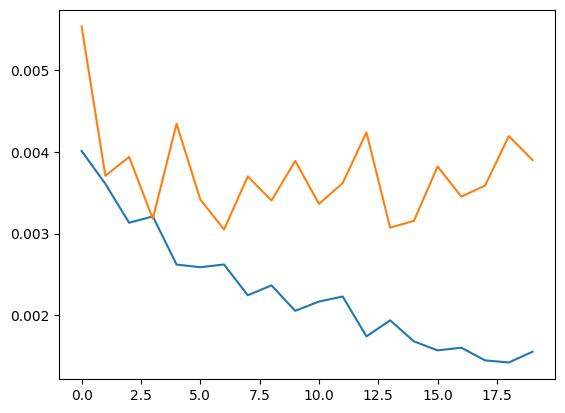

In [52]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

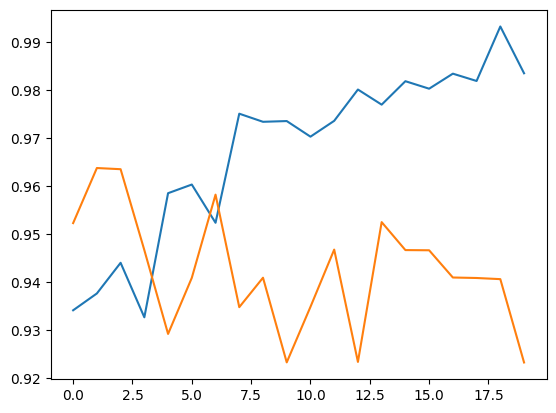

In [53]:
plt.plot(history.history['AUC'])
plt.plot(history.history['val_AUC'])

## Try out Different optimizers with learning rates

In [89]:
def preprocess(df, target):

    df.isnull().sum()

    X= df.drop(columns=[target])
    y=df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)


    sc= StandardScaler()
    X_train_sc = sc.fit_transform(X_train)
    X_test_sc = sc.transform(X_test)

In [90]:
preprocess(df, 'Class')

In [57]:
def creat_model(optimizer):

    model = Sequential()

    model.add(Dense( 256,activation ='relu', input_dim= X_train.shape[1]))
    
    # Hidden Layer 1
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    
    # Hidden Layer 2
    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))
    
    # Hidden Layer 3
    model.add(Dense(32, activation='relu'))
    
    # Output Layer
    model.add(Dense(1, activation='sigmoid'))

    model.compile( loss='binary_crossentropy', 
                   metrics=['AUC'],
                   optimizer= optimizer
                 )
    return model

In [58]:
optimizer_configs = {
    "Adam": [0.01, 0.001, 0.0005],
    "SGD": [0.1, 0.01, 0.001],
    "RMSprop": [0.01, 0.001]
}

histories = {}

In [59]:
for opt_name, lr_list in optimizer_configs.items():

    for lr in lr_list:

        config_name = f"{opt_name}_lr{lr}"
        print(f"\nTraining: {config_name}")

        # Create optimizer dynamically
        optimizer = getattr(keras.optimizers, opt_name)(learning_rate=lr)  # keras.optimizers.opt_name(learning_rate=lr)

        model = creat_model(optimizer)

        history = model.fit(
            X_train_sc,
            y_train,
            validation_data=(X_test_sc, y_test),
            epochs=30,
            batch_size=4096,
            verbose=0
        )

        histories[config_name] = history


Training: Adam_lr0.01

Training: Adam_lr0.001

Training: Adam_lr0.0005

Training: SGD_lr0.1

Training: SGD_lr0.01

Training: SGD_lr0.001

Training: RMSprop_lr0.01

Training: RMSprop_lr0.001


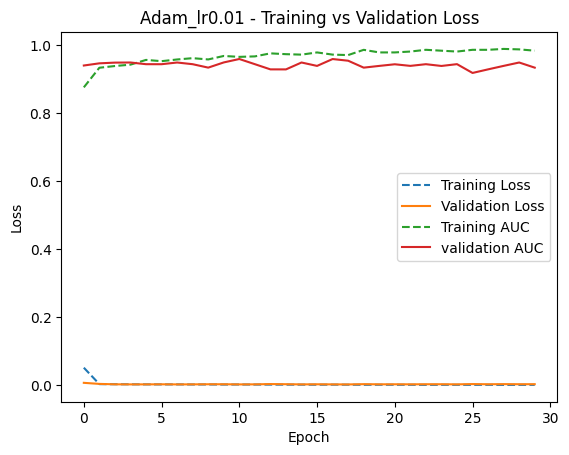

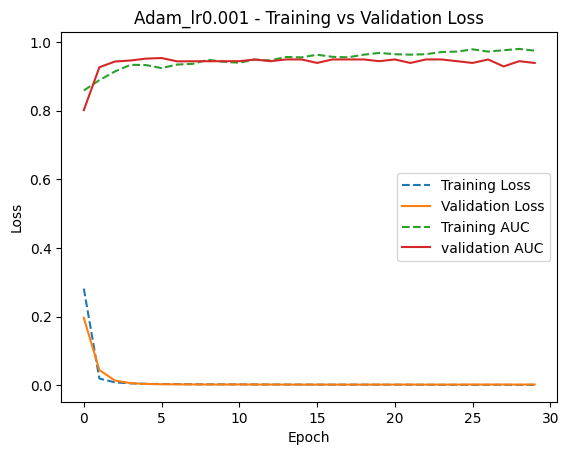

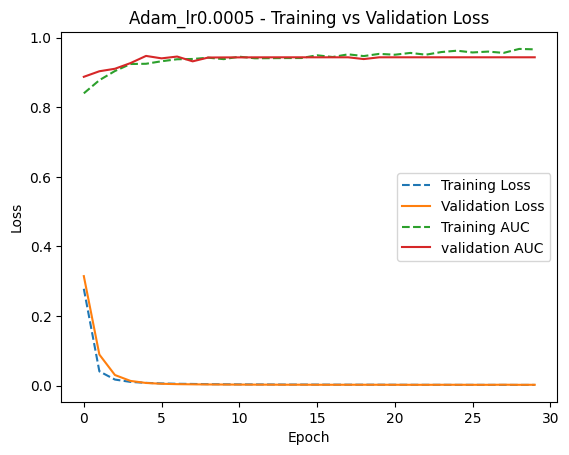

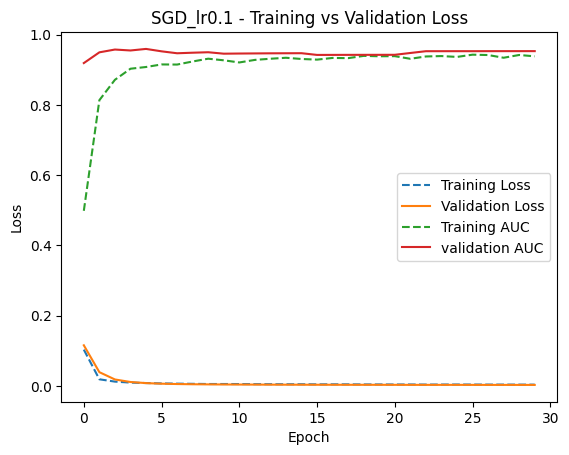

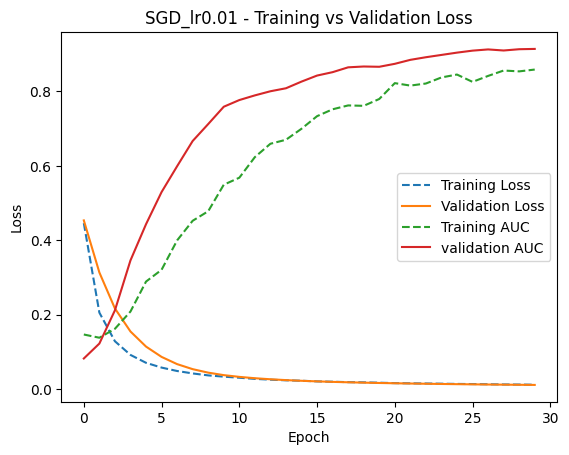

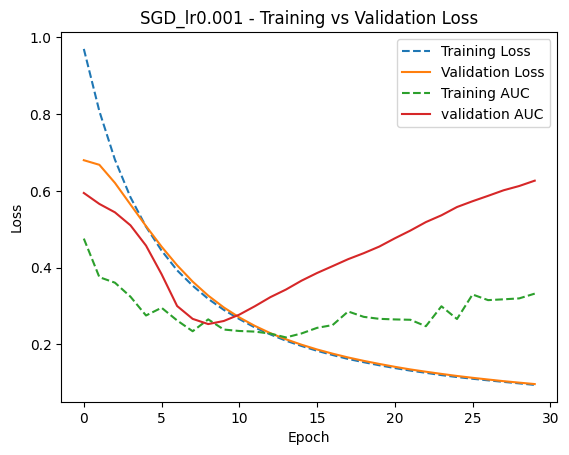

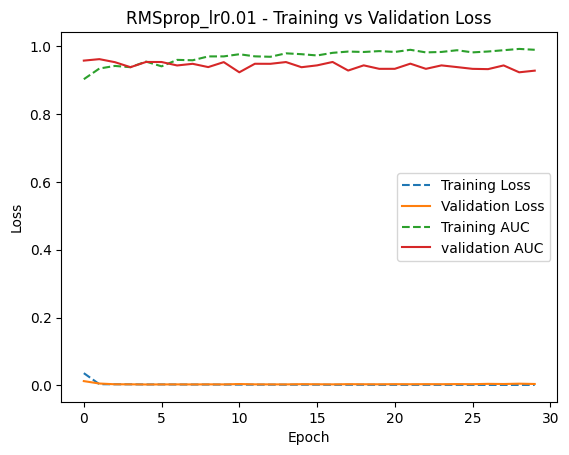

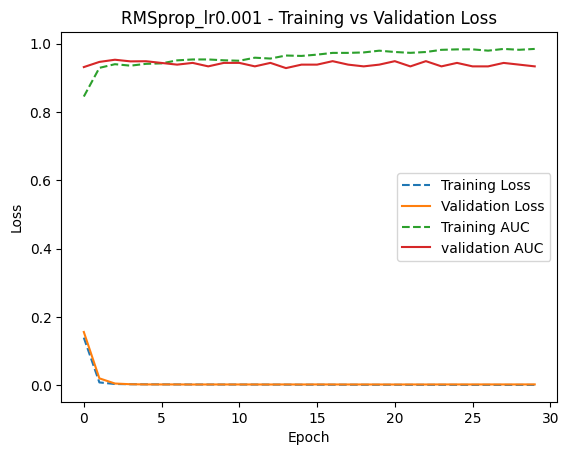

In [60]:

for name, history in histories.items():

    plt.figure()

    # Training loss
    plt.plot(history.history['loss'], linestyle='--', label='Training Loss')
    # Validation loss
    plt.plot(history.history['val_loss'], label='Validation Loss')

    # Training loss
    plt.plot(history.history['AUC'], linestyle='--', label='Training AUC')
    # Validation loss
    plt.plot(history.history['val_AUC'], label='validation AUC')

    plt.title(f"{name} - Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

In [66]:
results={}
for name, history in histories.items():

    best_auc = max(history.history['val_AUC'])
    results[f"{opt_name}_lr{lr}"] = best_auc


0.9529005289077759


In [92]:
var=0
for name , value in results.items():
    if value > var:
        var=value
        best_model=name
    

print('best model', best_model)
print('Best AUC',var)

best model RMSprop_lr0.001
Best AUC 0.9529005289077759


## Test on Unseen Data 

In [77]:
y_prob = model.predict(X_test_sc)
y_prob

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


array([[9.9999744e-01],
       [4.7329322e-05],
       [3.6751768e-05],
       ...,
       [1.8573169e-06],
       [1.6851561e-06],
       [1.8458148e-05]], dtype=float32)

In [81]:
# convert to class
y_pred = (y_prob > 0.5).astype(int)
y_pred

array([[1],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [80]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.92      0.79      0.85        98

    accuracy                           1.00     56962
   macro avg       0.96      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962

